In [42]:
# News Article Summarizer using NLP and TextRank
# Dataset: BBC News Summary Dataset

In [49]:
# Import Libraries

import os
import zipfile
import numpy as np
import pandas as pd
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.text_rank import TextRankSummarizer
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [44]:
# Extract Dataset

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("/content/bbc")

# Dataset Paths

article_dir = "/content/bbc/BBC News Summary/News Articles/business"
summary_dir = "/content/bbc/BBC News Summary/Summaries/business"
files = sorted(os.listdir(article_dir))
print("Total Articles Found:", len(files))

Total Articles Found: 501


In [45]:
# TextRank Summarization Function

def summarize_article(article, num_sentences=5):
    parser = PlaintextParser.from_string(
        article,
        Tokenizer("english")
    )
    summarizer = TextRankSummarizer()
    summary = summarizer(
        parser.document,
        num_sentences
    )
    summary_text = " ".join(
        str(sentence)
        for sentence in summary
    )
    return summary_text

In [46]:
# Display Sample Article

sample_file = files[0]
with open(
    os.path.join(article_dir, sample_file),
    "r",
    encoding="latin-1"
) as f:
    sample_article = f.read()

with open(
    os.path.join(summary_dir, sample_file),
    "r",
    encoding="latin-1"
) as f:
    sample_human_summary = f.read()

sample_generated_summary = summarize_article(
    sample_article,
    5
)
print("=" * 70)
print("ORIGINAL ARTICLE")
print("=" * 70)
print(sample_article[:1500])
print("\n")
print("=" * 70)
print("BBC HUMAN SUMMARY")
print("=" * 70)
print(sample_human_summary)
print("\n")
print("=" * 70)
print("GENERATED SUMMARY")
print("=" * 70)
print(sample_generated_summary)

ORIGINAL ARTICLE
Court rejects $280bn tobacco case

A US government claim accusing the country's biggest tobacco companies of covering up the effects of smoking has been thrown out by an appeal court.

The demand for $280bn (Â£155bn) - filed by the Clinton administration in 1999 - was rejected in a 2-1 decision. The court in Washington found that the case could not be brought under federal anti-racketeering laws. Among the accused were Altria Group, RJ Reynolds Tobacco, Lorillard Tobacco, Liggett Group and Brown and Williamson. In its case, the government claimed tobacco firms manipulated nicotine levels to increase addiction, targeted teenagers with multi-billion dollar advertising campaigns, lied about the dangers of smoking and ignored research to the contrary.

Prosecutors wanted the cigarette firms to surrender $280bn in profits accumulated over the past 50 years and impose tougher rules on marketing their products. But the Court of Appeals for the District of Columbia ruled that 

In [47]:
# Compression Ratio

original_words = len(sample_article.split())
summary_words = len(sample_generated_summary.split())
compression_ratio = (
    (original_words - summary_words)
    / original_words
) * 100
print("\n")
print("=" * 70)
print("COMPRESSION ANALYSIS")
print("=" * 70)
print("Original Length :", original_words)
print("Summary Length  :", summary_words)
print("Compression Ratio:", round(compression_ratio, 2), "%")



COMPRESSION ANALYSIS
Original Length : 227
Summary Length  : 127
Compression Ratio: 44.05 %


In [48]:
# ROUGE Evaluation

files = files[:50]
rouge1 = []
rouge2 = []
rougeL = []
scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)
for file in files:
    with open(
        os.path.join(article_dir, file),
        "r",
        encoding="latin-1"
    ) as f:
        article = f.read()
    with open(
        os.path.join(summary_dir, file),
        "r",
        encoding="latin-1"
    ) as f:
        human_summary = f.read()
    generated_summary = summarize_article(
        article,
        5
    )
    scores = scorer.score(
        human_summary,
        generated_summary
    )
    rouge1.append(
        scores["rouge1"].fmeasure
    )
    rouge2.append(
        scores["rouge2"].fmeasure
    )
    rougeL.append(
        scores["rougeL"].fmeasure
    )

# Final Results

avg_rouge1 = np.mean(rouge1)
avg_rouge2 = np.mean(rouge2)
avg_rougeL = np.mean(rougeL)
results = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L"
    ],
    "Score": [
        round(avg_rouge1 * 100, 2),
        round(avg_rouge2 * 100, 2),
        round(avg_rougeL * 100, 2)
    ]
})

print("\n")
print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)
print(results)



MODEL PERFORMANCE
    Metric  Score
0  ROUGE-1  63.72
1  ROUGE-2  52.56
2  ROUGE-L  45.11


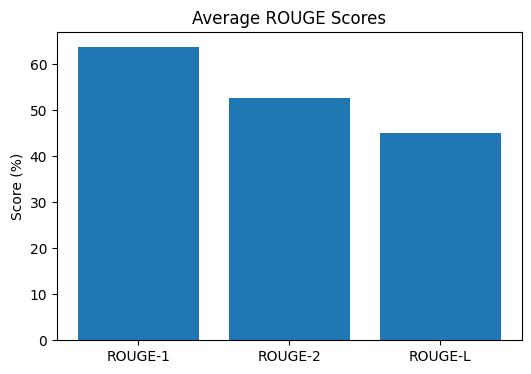

In [50]:
metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
scores = [63.72, 52.56, 45.11]
plt.figure(figsize=(6,4))
plt.bar(metrics, scores)
plt.title("Average ROUGE Scores")
plt.ylabel("Score (%)")
plt.show()

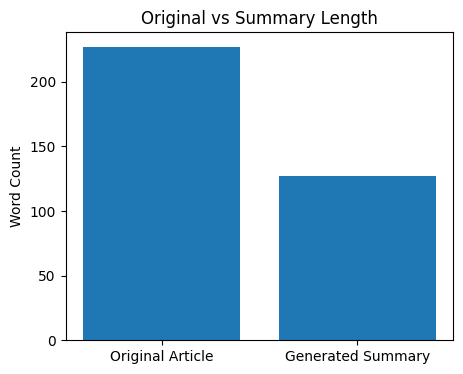

In [51]:
plt.figure(figsize=(5,4))
labels = ["Original Article", "Generated Summary"]
lengths = [original_words, summary_words]
plt.bar(labels, lengths)
plt.title("Original vs Summary Length")
plt.ylabel("Word Count")
plt.show()

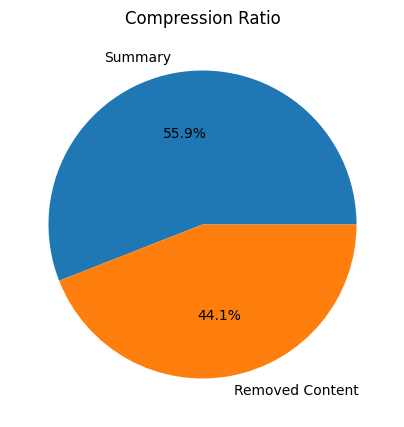

In [52]:
plt.figure(figsize=(5,5))
sizes = [
    summary_words,
    original_words - summary_words
]
labels = [
    "Summary",
    "Removed Content"
]
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%"
)
plt.title("Compression Ratio")
plt.show()